# **Day 53: Bayesian Machine Learning and MCMC**
*Module 9 - Probabilistic ML, Time Series and Semi-Supervised Learning*

So far we estimated **one best** set of parameters (MLE/MAP, Day 14). **Bayesian inference** keeps the whole **posterior distribution** over parameters:
$$p(\theta\mid D) = \frac{p(D\mid\theta)\,p(\theta)}{p(D)}$$
Benefits: honest uncertainty (credible intervals), principled use of prior knowledge, natural regularisation, and predictions that average over plausible models. Essential when data are scarce, as in many field studies.

> Bayesian ML treats model parameters as uncertain quantities with probability distributions. Prior knowledge is combined with the data to give a posterior distribution, and MCMC draws samples from it when no formula exists.
>
> *Example:* Instead of "the slope coefficient is 0.8", a Bayesian model says "it is between 0.6 and 1.0 with 95% probability".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(53)

## **1. Conjugate Updating: Beta-Binomial**
We estimate the **accuracy** $\theta$ of a land-cover map from field checks. Prior Beta($\alpha, \beta$); after $k$ correct of $n$ checks the posterior is Beta($\alpha + k, \beta + n - k$). The posterior after one batch is the prior for the next.

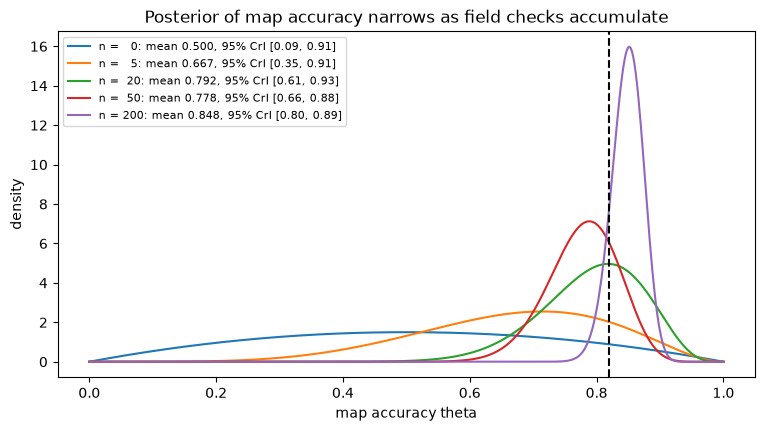

In [2]:
true_acc = 0.82
checks = rng.random(200) < true_acc
theta = np.linspace(0, 1, 500)
a0, b0 = 2, 2                                                 # weak prior centred at 0.5
plt.figure(figsize=(9, 4.5))
for n in [0, 5, 20, 50, 200]:
    k = checks[:n].sum(); post = stats.beta(a0 + k, b0 + n - k)
    lo, hi = post.ppf([0.025, 0.975])
    plt.plot(theta, post.pdf(theta), label=f"n = {n:>3}: mean {post.mean():.3f}, 95% CrI [{lo:.2f}, {hi:.2f}]")
plt.axvline(true_acc, c="k", ls="--"); plt.xlabel("map accuracy theta"); plt.ylabel("density"); plt.legend(fontsize=8)
plt.title("Posterior of map accuracy narrows as field checks accumulate"); plt.show()

A **credible interval** has the interpretation people usually (wrongly) give confidence intervals: "given the data and prior, there is a 95% probability that $\theta$ is in this interval".

## **2. Bayesian Linear Regression**
Prior $\mathbf w\sim\mathcal N(0, \alpha^{-1}I)$, noise precision $\beta$. The posterior is Gaussian:
$$S_N = (\alpha I + \beta X^\top X)^{-1},\qquad \mathbf m_N = \beta S_NX^\top\mathbf y$$
Predictive distribution for a new $\mathbf x$: mean $\mathbf m_N^\top\phi(\mathbf x)$, variance $\frac1\beta + \phi(\mathbf x)^\top S_N\phi(\mathbf x)$ (noise + parameter uncertainty).

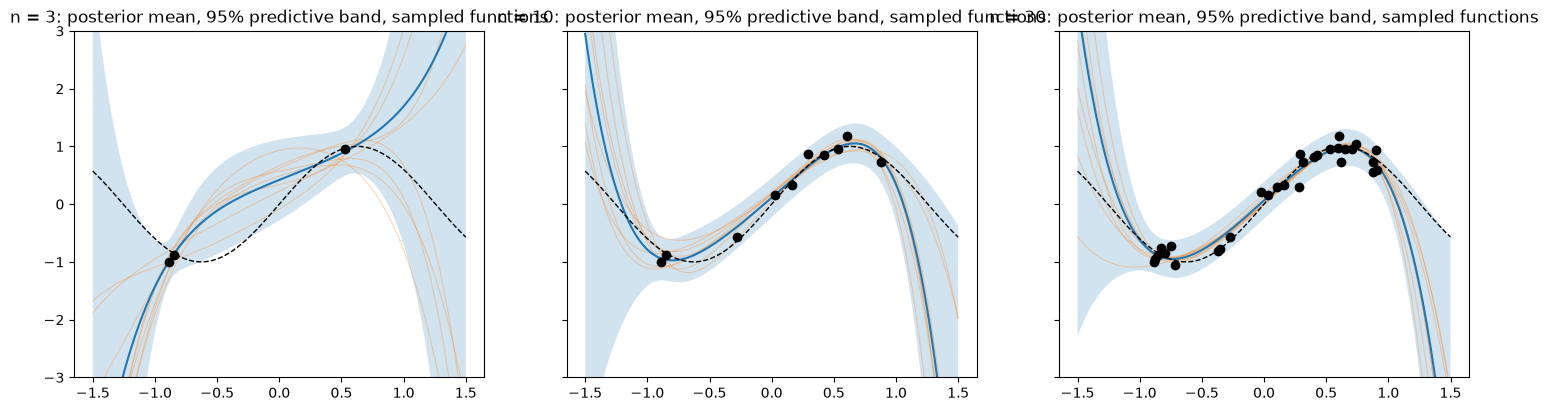

In [3]:
def features(x, degree=5):
    return np.vander(x, degree + 1, increasing=True)

x_all = rng.uniform(-1, 1, 30); y_all = np.sin(2.5 * x_all) + rng.normal(0, 0.15, 30)
alpha, beta = 2.0, 1 / 0.15 ** 2
xg = np.linspace(-1.5, 1.5, 300); Phig = features(xg)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, n in zip(axes, [3, 10, 30]):
    Phi = features(x_all[:n])
    S_N = np.linalg.inv(alpha * np.eye(Phi.shape[1]) + beta * Phi.T @ Phi); m_N = beta * S_N @ Phi.T @ y_all[:n]
    mean = Phig @ m_N; sd = np.sqrt(1 / beta + np.sum(Phig @ S_N * Phig, axis=1))
    for w in rng.multivariate_normal(m_N, S_N, 8):
        ax.plot(xg, Phig @ w, c="C1", alpha=0.3, lw=0.8)                       # functions sampled from the posterior
    ax.plot(xg, mean, "C0"); ax.fill_between(xg, mean - 2 * sd, mean + 2 * sd, alpha=0.2)
    ax.scatter(x_all[:n], y_all[:n], c="k", zorder=3); ax.plot(xg, np.sin(2.5 * xg), "k--", lw=1)
    ax.set(title=f"n = {n}: posterior mean, 95% predictive band, sampled functions", ylim=(-3, 3))
plt.show()

Uncertainty is **large where there is no data** (edges, and everywhere when n = 3) and shrinks near observations. A plain least-squares fit gives no such warning. Note that $\alpha/\beta$ plays the role of the Ridge penalty (Day 14, 24).

## **3. Markov Chain Monte Carlo: Metropolis-Hastings**
Most posteriors have no closed form. MCMC builds a Markov chain whose stationary distribution **is** the posterior; we only need the posterior **up to a constant** (prior x likelihood).

**Random-walk Metropolis:**
1. Propose $\theta' = \theta + \varepsilon$, $\varepsilon\sim\mathcal N(0, s^2)$
2. Accept with probability $\min\left(1, \frac{p(\theta'\mid D)}{p(\theta\mid D)}\right)$ (computed in log space)
3. Otherwise stay at $\theta$

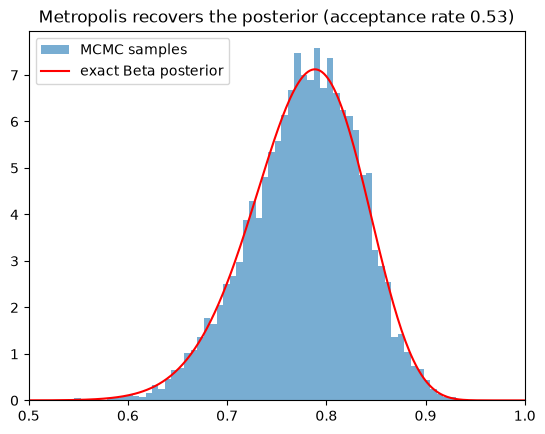

In [4]:
def metropolis(log_post, theta0, n_samples=20000, step=0.1, seed=0):
    r = np.random.default_rng(seed); theta = np.array(theta0, float); lp = log_post(theta)
    chain = np.empty((n_samples, len(theta))); accepted = 0
    for t in range(n_samples):
        prop = theta + r.normal(0, step, len(theta)); lp_prop = log_post(prop)
        if np.log(r.random()) < lp_prop - lp:
            theta, lp = prop, lp_prop; accepted += 1
        chain[t] = theta
    return chain, accepted / n_samples

# Check against the conjugate answer: Beta posterior of the map accuracy (n = 50 checks)
k50 = checks[:50].sum()
def log_post_acc(th):
    p = th[0]
    if not 0 < p < 1: return -np.inf
    return stats.beta(a0, b0).logpdf(p) + stats.binom(50, p).logpmf(k50)
chain, acc_rate = metropolis(log_post_acc, [0.5], step=0.1)
samples = chain[2000:, 0]
plt.hist(samples, bins=60, density=True, alpha=0.6, label="MCMC samples")
plt.plot(theta, stats.beta(a0 + k50, b0 + 50 - k50).pdf(theta), "r", label="exact Beta posterior")
plt.xlim(0.5, 1); plt.legend(); plt.title(f"Metropolis recovers the posterior (acceptance rate {acc_rate:.2f})"); plt.show()

## **4. Diagnostics**
- **Trace plot**: should look like a "hairy caterpillar", no trends.
- **Burn-in**: discard early samples before the chain reaches the posterior.
- **Step size**: too small = high acceptance but slow exploration; too large = most proposals rejected. Aim for ~0.2-0.5 acceptance in random-walk Metropolis.
- **Autocorrelation / effective sample size (ESS)**: correlated samples carry less information (Day 10).
- **R-hat** (Gelman-Rubin): run several chains from different starts; R-hat close to 1 (< 1.01) means they agree.

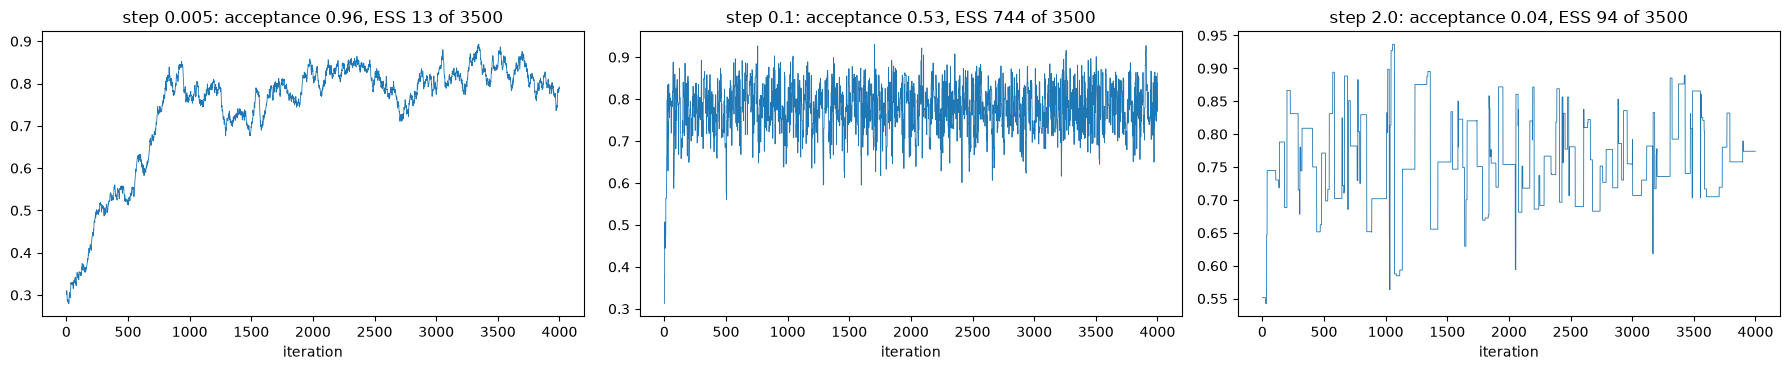

R-hat over 4 chains started at 0.1 / 0.4 / 0.7 / 0.95: 1.0005


In [5]:
def ess(x, max_lag=500):
    x = x - x.mean(); n = len(x); acf = np.correlate(x, x, "full")[n - 1:n - 1 + max_lag] / (x.var() * n)
    cut = np.argmax(acf < 0.05) if np.any(acf < 0.05) else max_lag
    return n / (1 + 2 * acf[1:cut].sum())

def rhat(chains):
    m, n = chains.shape; means = chains.mean(1); W = chains.var(1, ddof=1).mean(); B = n * means.var(ddof=1)
    return np.sqrt(((n - 1) / n * W + B / n) / W)

fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
for ax, step in zip(axes, [0.005, 0.1, 2.0]):
    ch, ar = metropolis(log_post_acc, [0.3], n_samples=4000, step=step)
    ax.plot(ch[:, 0], lw=0.6); ax.set(title=f"step {step}: acceptance {ar:.2f}, ESS {ess(ch[500:, 0]):.0f} of 3500", xlabel="iteration")
plt.tight_layout(); plt.show()
chains4 = np.array([metropolis(log_post_acc, [s0], n_samples=5000, step=0.1, seed=i)[0][1000:, 0] for i, s0 in enumerate([0.1, 0.4, 0.7, 0.95])])
print(f"R-hat over 4 chains started at 0.1 / 0.4 / 0.7 / 0.95: {rhat(chains4):.4f}")

## **5. Bayesian Logistic Regression by MCMC**
No conjugate prior exists for logistic regression, so MCMC is needed. The posterior of each coefficient gives credible intervals; the **posterior predictive** probability averages over all plausible coefficient vectors.

In [6]:
n = 60
slope = rng.uniform(0, 45, n); rain = rng.uniform(0, 1, n)
logit = -4 + 0.12 * slope + 1.5 * rain
y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
Xd = np.c_[np.ones(n), (slope - slope.mean()) / slope.std(), (rain - rain.mean()) / rain.std()]

def log_post_logit(w, prior_sd=2.5):
    z = Xd @ w
    return np.sum(y * z - np.logaddexp(0, z)) + stats.norm(0, prior_sd).logpdf(w).sum()

chain, ar = metropolis(log_post_logit, np.zeros(3), n_samples=30000, step=0.25)
post = chain[5000::5]
summary = pd.DataFrame({"mean": post.mean(0), "sd": post.std(0), "2.5%": np.percentile(post, 2.5, 0), "97.5%": np.percentile(post, 97.5, 0)},
                       index=["intercept", "slope (std)", "rain (std)"])
print(f"acceptance {ar:.2f} | ESS per parameter: {[round(ess(post[:, j])) for j in range(3)]}")
summary.round(3)

acceptance 0.55 | ESS per parameter: [1472, 1315, 1722]


,mean,sd,2.5%,97.5%
intercept,-0.990,0.336,-1.674,-0.352
slope (std),1.131,0.372,0.447,1.909
rain (std),0.141,0.320,-0.483,0.802


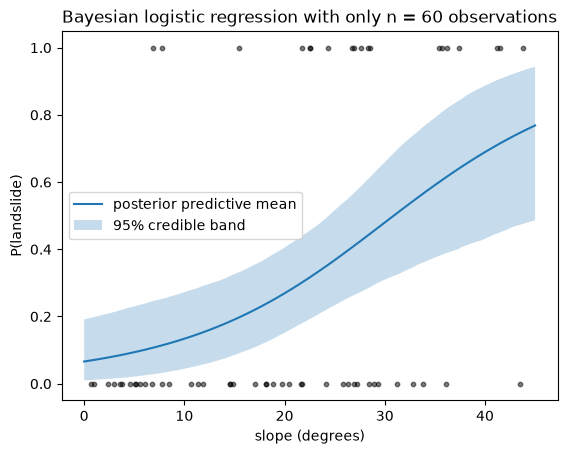

In [7]:
grid_slope = np.linspace(0, 45, 100)
Xg = np.c_[np.ones(100), (grid_slope - slope.mean()) / slope.std(), np.zeros(100)]
P = 1 / (1 + np.exp(-(Xg @ post.T)))                                   # (grid, posterior samples)
plt.plot(grid_slope, P.mean(1), "C0", label="posterior predictive mean")
plt.fill_between(grid_slope, *np.percentile(P, [2.5, 97.5], axis=1), alpha=0.25, label="95% credible band")
plt.scatter(slope, y, c="k", s=10, alpha=0.5); plt.xlabel("slope (degrees)"); plt.ylabel("P(landslide)"); plt.legend()
plt.title(f"Bayesian logistic regression with only n = {n} observations"); plt.show()

# **Part 2: Going Deeper - Hierarchical Models (Partial Pooling)**

Yield trials in 8 districts, with very different sample sizes. Options:
- **No pooling**: each district's own mean (noisy for small districts).
- **Complete pooling**: one global mean (ignores real differences).
- **Partial pooling** (hierarchical): district means $\theta_j\sim\mathcal N(\mu, \tau^2)$; small districts "borrow strength" and are **shrunk** towards the global mean.

With known within-district noise $\sigma$, the posterior mean of $\theta_j$ is a precision-weighted average: $\hat\theta_j = \frac{n_j/\sigma^2\,\bar y_j + 1/\tau^2\,\mu}{n_j/\sigma^2 + 1/\tau^2}$. We sample $\mu$, $\log\tau$ by Metropolis on the marginal likelihood and then draw $\theta_j$.

In [8]:
J = 8; n_j = np.array([3, 5, 8, 12, 20, 40, 60, 100]); true_theta = rng.normal(3.0, 0.4, J); sigma = 0.8
data = [rng.normal(true_theta[j], sigma, n_j[j]) for j in range(J)]
ybar = np.array([d.mean() for d in data]); se2 = sigma ** 2 / n_j

def log_post_hyper(h):
    mu, log_tau = h; tau2 = np.exp(2 * log_tau)
    return np.sum(stats.norm(mu, np.sqrt(tau2 + se2)).logpdf(ybar)) + stats.norm(3, 5).logpdf(mu) + stats.norm(-1, 1).logpdf(log_tau)

hchain, _ = metropolis(log_post_hyper, [3.0, -1.0], n_samples=30000, step=0.15)
hpost = hchain[5000::10]
theta_draws = []
for mu, log_tau in hpost:
    tau2 = np.exp(2 * log_tau); prec = 1 / se2 + 1 / tau2
    theta_draws.append(rng.normal((ybar / se2 + mu / tau2) / prec, np.sqrt(1 / prec)))
theta_draws = np.array(theta_draws)
res = pd.DataFrame({"n": n_j, "true": true_theta, "no pooling": ybar, "partial pooling": theta_draws.mean(0), "complete pooling": np.mean(np.concatenate(data))})
print(res.round(3))
for name in ["no pooling", "partial pooling", "complete pooling"]:
    print(f"{name:<17} RMSE vs true district means: {np.sqrt(np.mean((res[name] - res.true) ** 2)):.3f}")

     n   true  no pooling  partial pooling  complete pooling
0    3  3.419       3.783            3.327             2.993
1    5  3.357       3.114            3.092             2.993
2    8  3.825       3.741            3.445             2.993
3   12  2.677       2.375            2.612             2.993
4   20  3.266       3.210            3.174             2.993
5   40  2.899       2.788            2.830             2.993
6   60  3.211       3.210            3.195             2.993
7  100  3.000       2.887            2.899             2.993
no pooling        RMSE vs true district means: 0.200
partial pooling   RMSE vs true district means: 0.177
complete pooling  RMSE vs true district means: 0.393


Small districts are pulled towards the overall mean; large ones keep their own estimate. Partial pooling usually gives the lowest error. Hierarchical models are natural for nested data: pixels in fields, fields in villages, plots in sites.

### Probabilistic programming
Real Bayesian work uses **PyMC**, **NumPyro** or **Stan**: we write the model; they run efficient samplers (Hamiltonian Monte Carlo / NUTS) and give diagnostics (with ArviZ). A PyMC version of the logistic model:
```python
import pymc as pm
with pm.Model():
    w = pm.Normal("w", 0, 2.5, shape=3)
    pm.Bernoulli("y", logit_p=pm.math.dot(Xd, w), observed=y)
    idata = pm.sample(2000, tune=1000, chains=4)      # NUTS sampler, R-hat and ESS in az.summary(idata)
```

## **Practice Problems**
1. Use a strong prior Beta(80, 20) for the map accuracy. How many field checks are needed before the posterior mean is within 0.02 of the truth?
2. In Bayesian linear regression, increase `alpha` to 50. What happens to the posterior functions?
3. Tune the Metropolis step for the logistic model to get an acceptance rate of 0.25-0.4 and report the ESS.
4. *(Advanced)* Compute the posterior probability that the slope coefficient is > 0 and that rain's effect is larger than slope's (on the standardised scale).

In [9]:
# Solution 1
for n_ in [0, 20, 50, 100, 200]:
    k_ = checks[:n_].sum(); print(f"n = {n_:>3}: posterior mean {(80 + k_) / (100 + n_):.3f}")
# Solution 2
Phi = features(x_all); S_N = np.linalg.inv(50 * np.eye(6) + beta * Phi.T @ Phi); m_N = beta * S_N @ Phi.T @ y_all
print("coefficients shrink towards 0 (stronger prior):", m_N.round(3))
# Solution 3
for st in [0.1, 0.25, 0.5]:
    ch, ar_ = metropolis(log_post_logit, np.zeros(3), n_samples=15000, step=st)
    print(f"step {st}: acceptance {ar_:.2f}, ESS(slope) {ess(ch[3000:, 1]):.0f}")
# Solution 4
print(f"P(slope effect > 0) = {np.mean(post[:, 1] > 0):.3f} | P(rain effect > slope effect) = {np.mean(post[:, 2] > post[:, 1]):.3f}")

n =   0: posterior mean 0.800
n =  20: posterior mean 0.808
n =  50: posterior mean 0.800
n = 100: posterior mean 0.805
n = 200: posterior mean 0.837
coefficients shrink towards 0 (stronger prior): [ 0.15   1.109 -0.09   0.037 -0.199 -0.168]


step 0.1: acceptance 0.81, ESS(slope) 186


step 0.25: acceptance 0.55, ESS(slope) 616


step 0.5: acceptance 0.27, ESS(slope) 819
P(slope effect > 0) = 1.000 | P(rain effect > slope effect) = 0.018


## **Key References**
- Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A., & Rubin, D. B. (2013). *Bayesian Data Analysis* (3rd ed.). CRC Press.
- McElreath, R. (2020). *Statistical Rethinking* (2nd ed.). CRC Press.
- Metropolis, N., Rosenbluth, A. W., Rosenbluth, M. N., Teller, A. H., & Teller, E. (1953). Equation of state calculations by fast computing machines. *The Journal of Chemical Physics*, 21(6), 1087-1092.
- Hastings, W. K. (1970). Monte Carlo sampling methods using Markov chains and their applications. *Biometrika*, 57(1), 97-109.
- Vehtari, A., Gelman, A., Simpson, D., Carpenter, B., & Burkner, P.-C. (2021). Rank-normalization, folding, and localization: An improved R-hat for assessing convergence of MCMC. *Bayesian Analysis*, 16(2), 667-718.
- Hoffman, M. D., & Gelman, A. (2014). The No-U-Turn sampler. *JMLR*, 15, 1593-1623.